# Isolator comparison: forward power, 2-3 GHz

Same forward-power sweep (analyzer on the coupler's forward port), run once with an isolator inserted before the bidirectional coupler and once without, to check whether the isolator meaningfully changes what's measured. Both sweeps: 2-3 GHz, 1 MHz steps, -20 dBm source.

Re-run the two sweep cells below to regenerate `data/forward_power_sweep_2-3GHz_1MHz.csv` and `data/no_isolator_sweep_2-3GHz_1MHz.csv` from scratch; the comparison cell at the bottom just loads whatever's currently in `data/`.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

from hp8673h import HP8673H
from e4403b import E4403B
from frequency_sweep import frequency_sweep

START_HZ = 2.0e9
STOP_HZ = 3.0e9
STEP_HZ = 1e6
POWER_DBM = -20

## With isolator

In [ ]:
gen = HP8673H("GPIB1::19::INSTR")
sa = E4403B("GPIB0::18::INSTR")
sa.set_center_span((START_HZ + STOP_HZ) / 2, STOP_HZ - START_HZ)

with_iso_freqs_hz, with_iso_power_dbm = frequency_sweep(
    gen, sa,
    start_hz=START_HZ, stop_hz=STOP_HZ, step_hz=STEP_HZ,
    power_dbm=POWER_DBM,
)

gen.close()
sa.close()

np.savetxt(
    "data/forward_power_sweep_2-3GHz_1MHz.csv",
    np.column_stack((with_iso_freqs_hz, with_iso_power_dbm)),
    delimiter=",", header="frequency_hz,power_dbm", comments="",
)
print(f"{len(with_iso_freqs_hz)} points collected")

## Without isolator

In [ ]:
gen = HP8673H("GPIB1::19::INSTR")
sa = E4403B("GPIB0::18::INSTR")
sa.set_center_span((START_HZ + STOP_HZ) / 2, STOP_HZ - START_HZ)

no_iso_freqs_hz, no_iso_power_dbm = frequency_sweep(
    gen, sa,
    start_hz=START_HZ, stop_hz=STOP_HZ, step_hz=STEP_HZ,
    power_dbm=POWER_DBM,
)

gen.close()
sa.close()

np.savetxt(
    "data/no_isolator_sweep_2-3GHz_1MHz.csv",
    np.column_stack((no_iso_freqs_hz, no_iso_power_dbm)),
    delimiter=",", header="frequency_hz,power_dbm", comments="",
)
print(f"{len(no_iso_freqs_hz)} points collected")

## Comparison

Loads whatever is currently saved in `data/` -- doesn't require re-running the sweeps above.

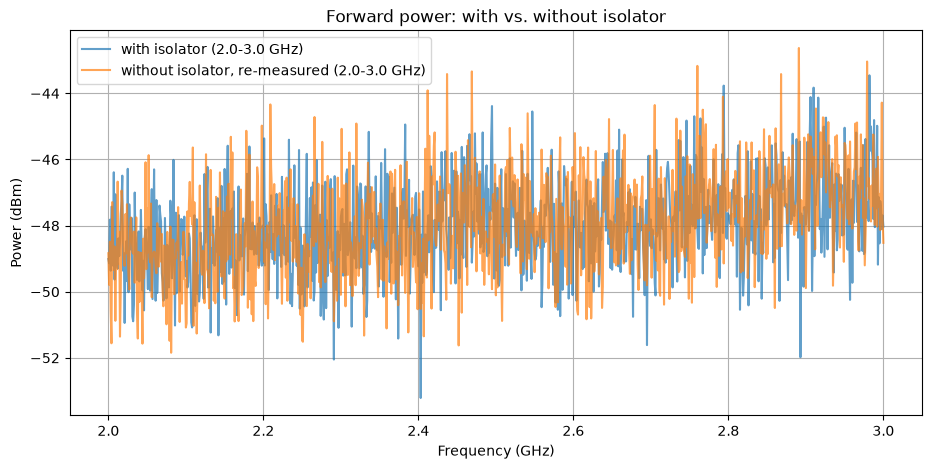

with isolator:    median -48.035 min -53.214 max -43.454
without isolator: median -48.054 min -51.845 max -42.628
mean abs diff (with vs without isolator): 1.4380669330669331 dB


In [1]:
with_iso = np.loadtxt("data/forward_power_sweep_2-3GHz_1MHz.csv", delimiter=",", skiprows=1)
no_iso = np.loadtxt("data/no_isolator_sweep_2-3GHz_1MHz.csv", delimiter=",", skiprows=1)

wf, wp = with_iso[:, 0], with_iso[:, 1]
nf, np_ = no_iso[:, 0], no_iso[:, 1]

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(wf / 1e9, wp, label="with isolator (2.0-3.0 GHz)", alpha=0.7)
ax.plot(nf / 1e9, np_, label="without isolator, re-measured (2.0-3.0 GHz)", alpha=0.7)
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Power (dBm)")
ax.set_title("Forward power: with vs. without isolator")
ax.legend()
ax.grid(True)
plt.show()

print("with isolator:    median", np.median(wp), "min", wp.min(), "max", wp.max())
print("without isolator: median", np.median(np_), "min", np_.min(), "max", np_.max())
print("mean abs diff (with vs without isolator):", np.mean(np.abs(wp - np_)), "dB")

## Isolator after coupler, no load, full reflection (reverse port, -25 dBm)

Setup changed again: isolator moved to AFTER the coupler, with nothing connected to its output -- an open circuit, so essentially all forward power reflects straight back through the isolator and out the coupler's reverse port. Analyzer is back on the REVERSE (reflected) power port. Power dropped to -25 dBm (extra caution, since this is closer to a full-reflection worst case than any previous test).

In [1]:
gen = HP8673H("GPIB1::19::INSTR")
sa = E4403B("GPIB0::18::INSTR")
sa.set_center_span((START_HZ + STOP_HZ) / 2, STOP_HZ - START_HZ)

reflect_freqs_hz, reflect_power_dbm = frequency_sweep(
    gen, sa,
    start_hz=START_HZ, stop_hz=STOP_HZ, step_hz=STEP_HZ,
    power_dbm=-25,
)

gen.close()
sa.close()

np.savetxt(
    "data/isolator_no_load_reflected_2-3GHz_1MHz.csv",
    np.column_stack((reflect_freqs_hz, reflect_power_dbm)),
    delimiter=",", header="frequency_hz,power_dbm", comments="",
)
print(f"{len(reflect_freqs_hz)} points collected")

1001 points collected


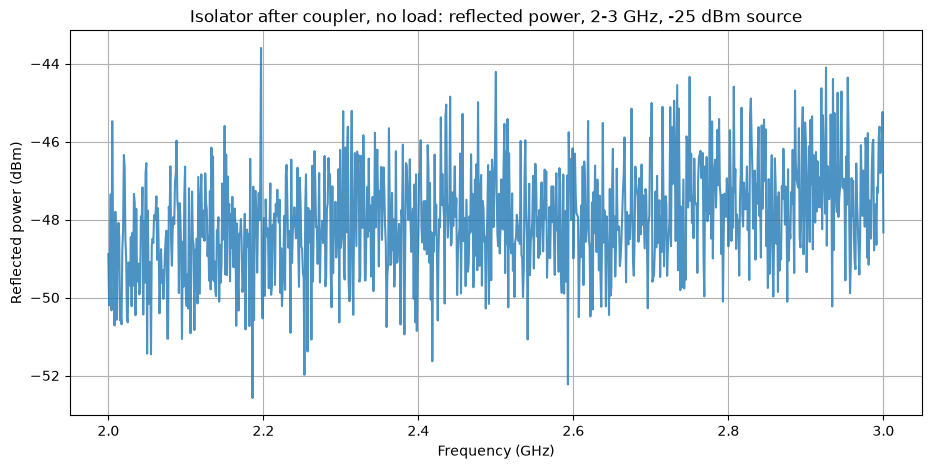

reflected power: median -48.038 min -52.577 max -43.6


In [2]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(reflect_freqs_hz / 1e9, reflect_power_dbm, alpha=0.8)
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Reflected power (dBm)")
ax.set_title("Isolator after coupler, no load: reflected power, 2-3 GHz, -25 dBm source")
ax.grid(True)
plt.show()

print("reflected power: median", np.median(reflect_power_dbm),
      "min", reflect_power_dbm.min(), "max", reflect_power_dbm.max())

## Same test, isolator removed (reverse port, -25 dBm, still no load)

Same reflected-power sweep as above, isolator taken back out. Coupler's reverse port straight into the analyzer, output still open (no load), power still at -25 dBm.

In [1]:
gen = HP8673H("GPIB1::19::INSTR")
sa = E4403B("GPIB0::18::INSTR")
sa.set_center_span((START_HZ + STOP_HZ) / 2, STOP_HZ - START_HZ)

no_iso_reflect_freqs_hz, no_iso_reflect_power_dbm = frequency_sweep(
    gen, sa,
    start_hz=START_HZ, stop_hz=STOP_HZ, step_hz=STEP_HZ,
    power_dbm=-25,
)

gen.close()
sa.close()

np.savetxt(
    "data/no_isolator_no_load_reflected_2-3GHz_1MHz.csv",
    np.column_stack((no_iso_reflect_freqs_hz, no_iso_reflect_power_dbm)),
    delimiter=",", header="frequency_hz,power_dbm", comments="",
)
print(f"{len(no_iso_reflect_freqs_hz)} points collected")

1001 points collected


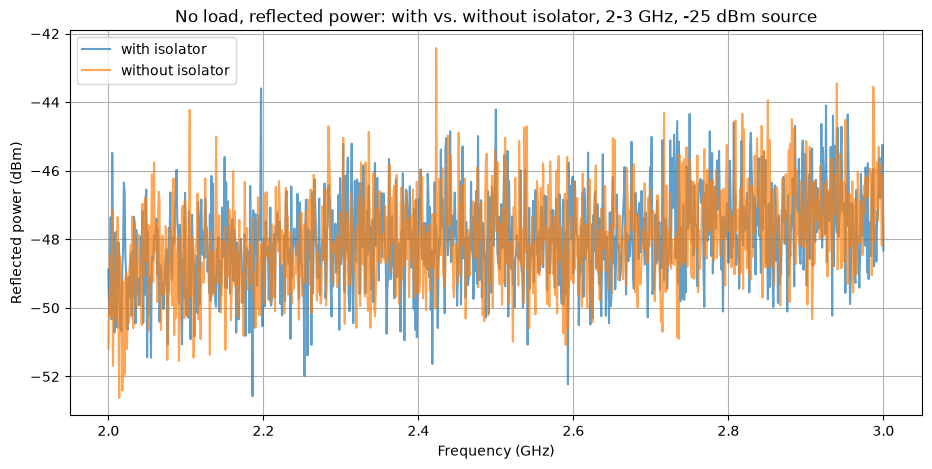

with isolator:    median -48.038 min -52.577 max -43.6
without isolator: median -48.01 min -52.628 max -42.421
mean abs diff: 1.4494005994005996 dB


In [2]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(reflect_freqs_hz / 1e9, reflect_power_dbm, label="with isolator", alpha=0.7)
ax.plot(no_iso_reflect_freqs_hz / 1e9, no_iso_reflect_power_dbm, label="without isolator", alpha=0.7)
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Reflected power (dBm)")
ax.set_title("No load, reflected power: with vs. without isolator, 2-3 GHz, -25 dBm source")
ax.legend()
ax.grid(True)
plt.show()

print("with isolator:    median", np.median(reflect_power_dbm),
      "min", reflect_power_dbm.min(), "max", reflect_power_dbm.max())
print("without isolator: median", np.median(no_iso_reflect_power_dbm),
      "min", no_iso_reflect_power_dbm.min(), "max", no_iso_reflect_power_dbm.max())
print("mean abs diff:", np.mean(np.abs(reflect_power_dbm - no_iso_reflect_power_dbm)), "dB")

## Terminated baseline: coupler direct into a 50 ohm load (no isolator, reverse port, -25 dBm)

Diagnostic for the surprising with/without-isolator result above (isolator should have given ~20 dB less reflected power, but didn't). Isolator removed entirely; coupler's output goes straight into a 50 ohm termination instead of being left open. Near-zero real reflection here, so whatever the reverse port still reads is the coupler's own directivity leakage floor -- if that floor matches the two no-load results above, it confirms the isolator's effect was being masked by the coupler's own leakage, not that the isolator is faulty.

In [1]:
gen = HP8673H("GPIB1::19::INSTR")
sa = E4403B("GPIB0::18::INSTR")
sa.set_center_span((START_HZ + STOP_HZ) / 2, STOP_HZ - START_HZ)

terminated_freqs_hz, terminated_power_dbm = frequency_sweep(
    gen, sa,
    start_hz=START_HZ, stop_hz=STOP_HZ, step_hz=STEP_HZ,
    power_dbm=-25,
)

gen.close()
sa.close()

np.savetxt(
    "data/coupler_terminated_reflected_2-3GHz_1MHz.csv",
    np.column_stack((terminated_freqs_hz, terminated_power_dbm)),
    delimiter=",", header="frequency_hz,power_dbm", comments="",
)
print(f"{len(terminated_freqs_hz)} points collected")

1001 points collected


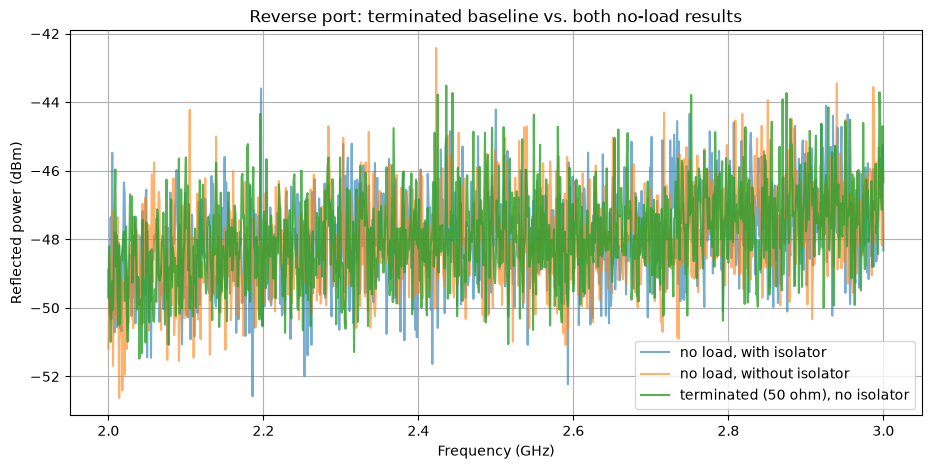

terminated:        median -47.902 min -51.478 max -43.52
no load, with isolator:    median -48.038
no load, without isolator: median -48.01
terminated vs no-load-with-isolator diff: -0.13599999999999568 dB
terminated vs no-load-without-isolator diff: -0.10799999999999699 dB


In [2]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(reflect_freqs_hz / 1e9, reflect_power_dbm, label="no load, with isolator", alpha=0.6)
ax.plot(no_iso_reflect_freqs_hz / 1e9, no_iso_reflect_power_dbm, label="no load, without isolator", alpha=0.6)
ax.plot(terminated_freqs_hz / 1e9, terminated_power_dbm, label="terminated (50 ohm), no isolator", alpha=0.8, linewidth=1.5)
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Reflected power (dBm)")
ax.set_title("Reverse port: terminated baseline vs. both no-load results")
ax.legend()
ax.grid(True)
plt.show()

print("terminated:        median", np.median(terminated_power_dbm),
      "min", terminated_power_dbm.min(), "max", terminated_power_dbm.max())
print("no load, with isolator:    median", np.median(reflect_power_dbm))
print("no load, without isolator: median", np.median(no_iso_reflect_power_dbm))
print("terminated vs no-load-with-isolator diff:",
      np.median(reflect_power_dbm) - np.median(terminated_power_dbm), "dB")
print("terminated vs no-load-without-isolator diff:",
      np.median(no_iso_reflect_power_dbm) - np.median(terminated_power_dbm), "dB")